# Item 1

In [23]:
frota <- 20

carro_dia <- c(16, 12, 15, 16, 19, 14, 15, 17, 15, 18,
               19, 13, 17, 13, 15, 15, 17, 16, 15, 17,
               16, 13, 18, 14, 13, 14, 14, 18, 16 )

litro_carro <- c(59, 51, 46, 67, 69, 52, 57, 57, 42, 67,
                66, 67, 44, 59, 68, 61, 47, 51, 66, 48,
                60, 62, 63, 45, 59, 46, 55, 52, 53, 60,
                66, 46, 47, 63, 52, 64, 48, 47, 62, 49,
                53, 49, 51, 44, 55, 59, 60, 45, 64, 55)

#### Amostragem

In [24]:
amostra_ordenada <- sort(carro_dia)
amostra_ordenada

[1] 12 13 13 13 13 14 14 14 14 15 15 15 15 15 15 16 16 16 16 16 17 17 17 17 18
[26] 18 18 19 19

In [25]:
n_simulacao <- 250

In [26]:
amostra <- sample(1:29, n_simulacao, replace = TRUE)
amostra

[1] 11  1  7 28 22  8  1 24 12  7 27 16  8 29 20  2 27 27  3 13 10 23  6  9 27
 [26]  7 16  8 14 16 10 23 29 15 22 19 15 19 26 25 18  6  9  5 24 12  4 18  1 10
 [51]  7  8 10 25  5 22 10 18  3 14 12  8  4 27 11 10 12  2  5 17 28 17 26 19 29
 [76] 16 12  1 13 22 10 16 29  6 25  9  1 26  1 29  8 18  8  7 24 12  9  7  2  8
[101] 12 24 29 26  8 14 20 12 29 11 25 18  5 29 18  5  3  1 27 22 21 12  1  4 13
[126] 25  4 25  6  8 27 12 20 17  4  1 16 27 26 23  6  3  5  3 20 29 24 23  6  4
[151] 29  5 10  2  3 29  5 21 20 22  2  8 13 15  6 22 20 27 22 13 29 14 27 18 28
[176]  2  5 27  2 11 27  4 26  6 18  1  7  9 28 25  7 16 16  8  6 21 27 22 23 25
[201]  4 10 19  8 15  7  3 25 12 27 21 22 12 17 17 26 28 25  1 27 26  3  3  2 27
[226] 26 18 13  3  5 19  8 28 21  5  1 28 11 17  7 16 13  1 24 15 24  9  7 18 11

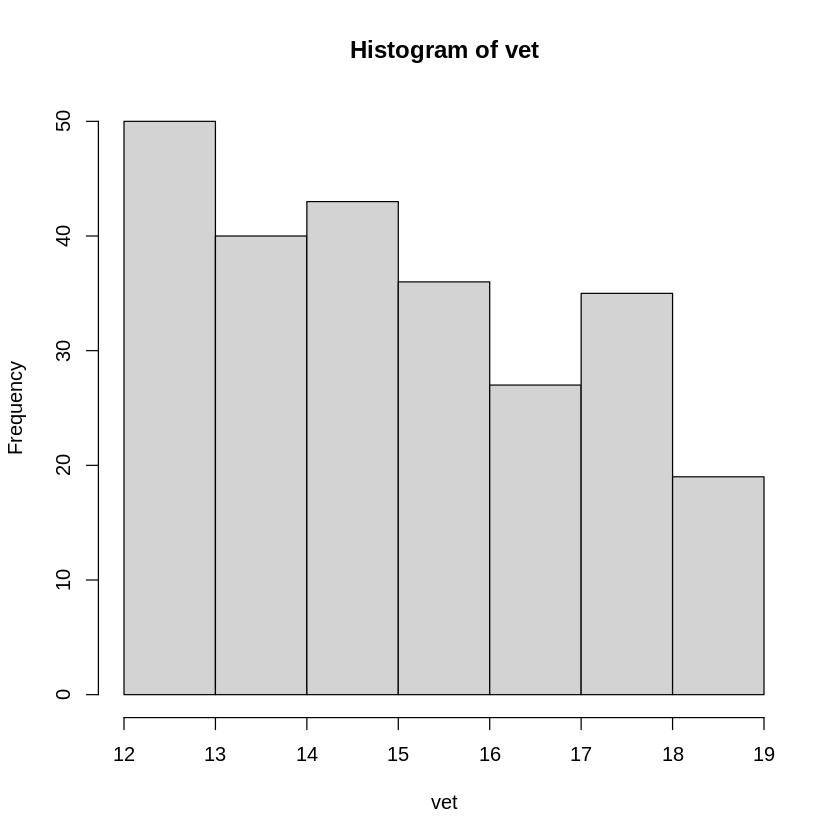

In [27]:
vet <- amostra_ordenada[amostra]

hist(vet)

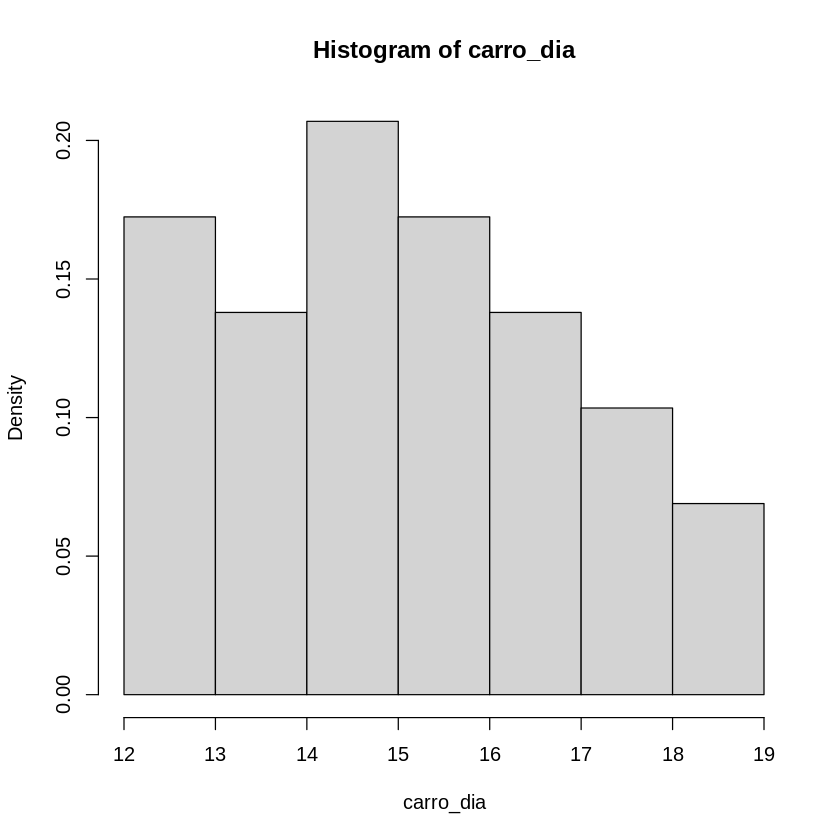

In [28]:
hist(carro_dia, probability = TRUE)

##  Simulação Monte Carlo

In [29]:
install.packages('triangle')
library(triangle)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [30]:
set.seed(1)
n_simulacao <- 3000

#### Matriz

In [31]:
n_sim <- 3000
n_carros <- 20

sample_ativos <- sample(carro_dia, n_sim, replace = TRUE)

matriz_ativos <- matrix(0, nrow = n_sim, ncol = n_carros)

for(i in 1:n_sim){
  k <- sample_ativos[i]  # quantos carros ativos naquele dia

  ativos_indices <- sample(1:n_carros, k, replace = FALSE)
  matriz_ativos[i, ativos_indices] <- 1
}

matriz_consumo <- matrix(
  sample(litro_carro, n_sim * n_carros, replace = TRUE),
  nrow = n_sim,
  ncol = n_carros
)

matriz_consumo <- matriz_consumo * matriz_ativos
matriz_preco <- matrix(
  rtriangle(n_simulacao, 6.10, 7),
  nrow=n_sim,
  ncol=n_carros
)

matriz_consumo <- matriz_consumo * matriz_ativos
gasto <- rowSums(matriz_consumo * matriz_preco)

In [32]:
summary(gasto)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3861    5083    5618    5651    6193    7702 

#### Resultados

In [33]:
resumo_gasto <- c(
    #media = mean(gasto), # valor esperado do gasto diario
    desvio_padrao = sd(gasto), # variacao em torno da media
    mediana = median(gasto), # valor central da distribuicao
    minimo = min(gasto), # menor gasto simulado
    maximo = max(gasto), # maior gasto simulado
    p05 = as.numeric(quantile(gasto, 0.05)), # limite inferior da faixa usual
    p25 = as.numeric(quantile(gasto, 0.25)), # primeiro quartil
    p75 = as.numeric(quantile(gasto, 0.75)), # terceiro quartil
    p90 = as.numeric(quantile(gasto, 0.90)), # limite superior da faixa usual
    p95 = as.numeric(quantile(gasto, 0.95)), # limite superior da faixa usual
    cv = sd(gasto) / mean(gasto) # dispersao relativa da simulacao
)

In [34]:
resumo_gasto_friendly <- data.frame(
    medida = names(resumo_gasto),
    valor = round(as.numeric(resumo_gasto), 2),
    row.names = NULL
)

print(resumo_gasto_friendly)

          medida   valor
1  desvio_padrao  735.45
2        mediana 5618.30
3         minimo 3860.93
4         maximo 7701.96
5            p05 4513.19
6            p25 5083.10
7            p75 6193.18
8            p90 6643.98
9            p95 6875.52
10            cv    0.13


### Gráficos

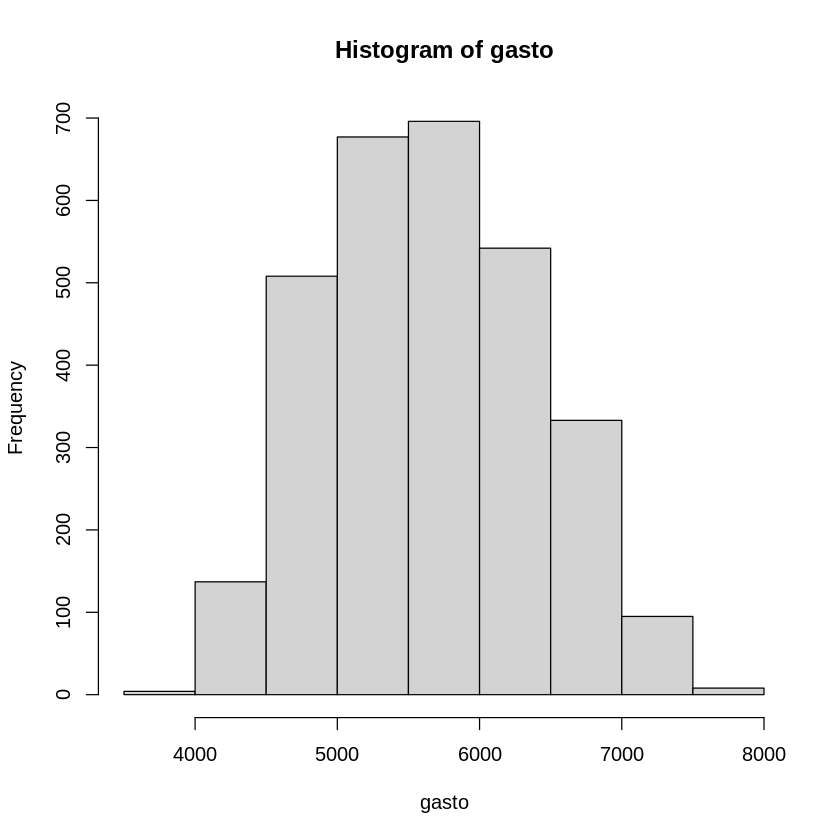

In [35]:
hist(gasto)

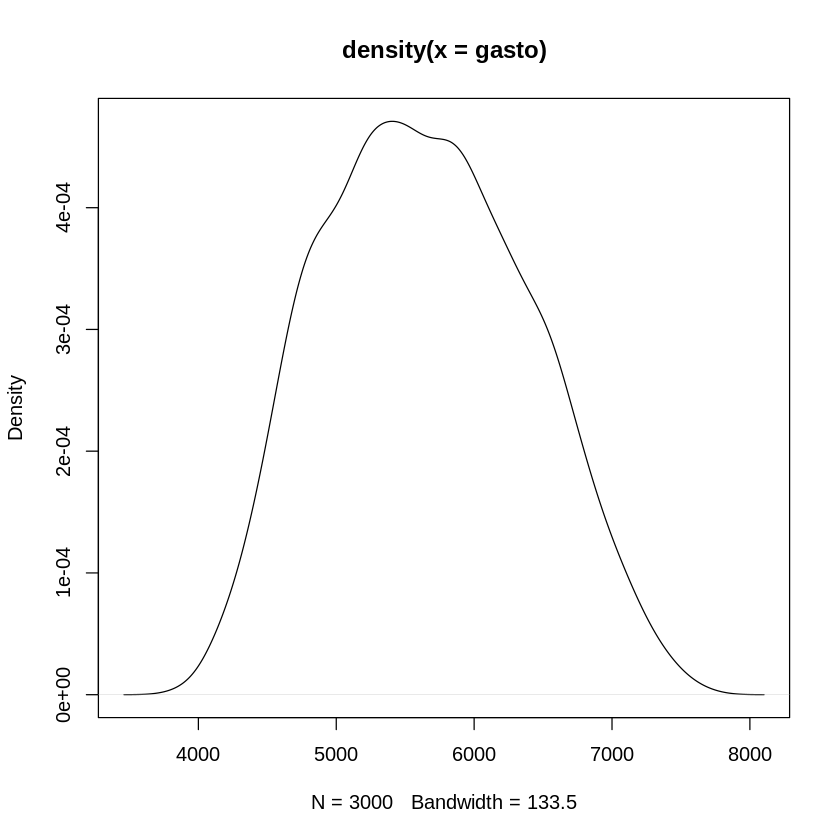

In [36]:
plot(density(gasto))

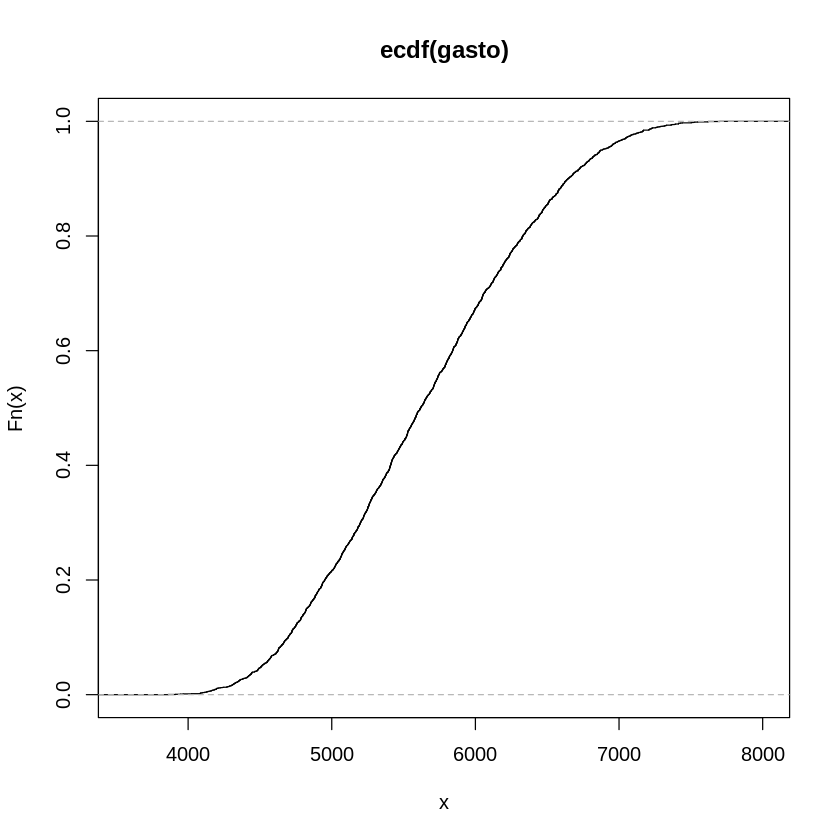

In [37]:
plot(ecdf(gasto))

- sortear o número de carros no dia
- sortear um número de litros a ser consumido
- sortear o valor da gasolina

In [38]:
# Estatísticas principais
custo_base <- quantile(gasto, 0.50)
custo_p90  <- quantile(gasto, 0.90)

# Contingência
contingencia <- custo_p90 - custo_base
percentual_contingencia <- (contingencia / custo_base) * 100

# Exibir resultados
cat(sprintf("P50 (mediana):      R$ %.2f\n", custo_base))
cat(sprintf("P90 (cenário risco): R$ %.2f\n", custo_p90))
cat(sprintf("Contingência:       R$ %.2f\n", contingencia))
cat(sprintf("Contingência %%:     %.2f%%\n", percentual_contingencia))

P50 (mediana):      R$ 5618.30
P90 (cenário risco): R$ 6643.98
Contingência:       R$ 1025.68
Contingência %:     18.26%


# item 2


In [39]:
set.seed(1)
n_simulacao <- 3000

# Parâmetros para a distribuição triangular (número de executivos)
exec_min <- 16
exec_moda <- 18
exec_max <- 22

# Gastos por pessoa no último almoço
gasto_por_pessoa <- c(347, 410, 349, 454, 370, 465, 445, 383, 358, 418, 377, 407, 467, 441, 428, 354, 384, 400, 378, 367, 421, 392, 337, 387, 452, 411, 339, 380, 371, 464, 369, 484, 458, 471, 362)

# Número de almoços nos últimos 10 anos
almocos_ultimos10 <- c(38, 45, 42, 37, 38, 31, 42, 37, 42, 40)

##  Simulação Monte Carlo

In [40]:
# Vetor para armazenar o custo anual de cada simulação
custo_anual <- numeric(n_simulacao)

# Loop sobre cada simulação (cada ano)
for(sim in 1:n_simulacao){
  # Determinar número de almoços naquele ano
  num_almocos <- sample(almocos_ultimos10, 1)

  # Somar custo de todos os almoços naquele ano
  custo_almocos_ano <- 0

  # Loop sobre cada almoço naquele ano
  for(alm in 1:num_almocos){
    # Gerar número de executivos presentes neste almoço
    num_executivos <- round(rtriangle(1, a = exec_min, b = exec_max, c = exec_moda))

    # Selecionar quem está presente (índices)
    presentes <- sample(1:exec_max, num_executivos, replace = FALSE)

    # Gerar gasto de cada executivo presente
    gastos_individuais <- sample(gasto_por_pessoa, num_executivos, replace = TRUE)

    # Custo deste almoço
    custo_almoço <- sum(gastos_individuais)

    # Acumular ao total do ano
    custo_almocos_ano <- custo_almocos_ano + custo_almoço
  }

  # Guardar custo anual da simulação
  custo_anual[sim] <- custo_almocos_ano
}


In [41]:
# Resumo estatístico do custo anual
resumo_custo <- c(
    media = mean(custo_anual), # valor esperado do custo anual
    desvio_padrao = sd(custo_anual), # variação absoluta
    mediana = median(custo_anual), # valor central
    minimo = min(custo_anual),
    maximo = max(custo_anual),
    p05 = as.numeric(quantile(custo_anual, 0.05)),
    p25 = as.numeric(quantile(custo_anual, 0.25)),
    p75 = as.numeric(quantile(custo_anual, 0.75)),
    p80 = as.numeric(quantile(custo_anual, 0.80)),
    p90 = as.numeric(quantile(custo_anual, 0.90)),
    p95 = as.numeric(quantile(custo_anual, 0.95)),
    cv = sd(custo_anual) / mean(custo_anual)
)

resumo_custo_friendly <- data.frame(
    medida = names(resumo_custo),
    valor = round(as.numeric(resumo_custo), 2),
    row.names = NULL
)

cat('\n--- Item 2: Resumo do custo anual (simulação) ---\n')
print(resumo_custo_friendly)


--- Item 2: Resumo do custo anual (simulação) ---
          medida     valor
1          media 294613.38
2  desvio_padrao  28699.88
3        mediana 294315.50
4         minimo 224586.00
5         maximo 348495.00
6            p05 232727.00
7            p25 280400.00
8            p75 315641.25
9            p80 317351.40
10           p90 331389.50
11           p95 339078.00
12            cv      0.10


In [42]:
summary(custo_anual)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 224586  280400  294316  294613  315641  348495 

In [43]:
# Estatísticas principais
custo_base <- quantile(custo_anual, 0.50)
custo_p90  <- quantile(custo_anual, 0.90)

# Contingência
contingencia <- custo_p90 - custo_base
percentual_contingencia <- (contingencia / custo_base) * 100

# Exibir resultados
cat(sprintf("P50 (mediana):      R$ %.2f\n", custo_base))
cat(sprintf("P90 (cenário risco): R$ %.2f\n", custo_p90))
cat(sprintf("Contingência:       R$ %.2f\n", contingencia))
cat(sprintf("Contingência %%:     %.2f%%\n", percentual_contingencia))

P50 (mediana):      R$ 294315.50
P90 (cenário risco): R$ 331389.50
Contingência:       R$ 37074.00
Contingência %:     12.60%


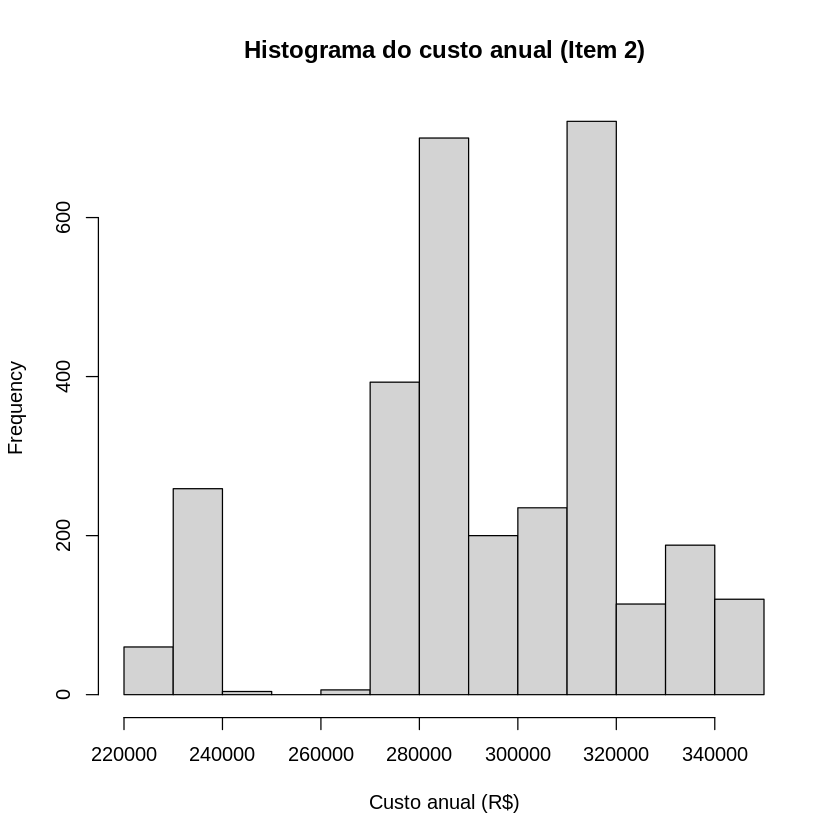

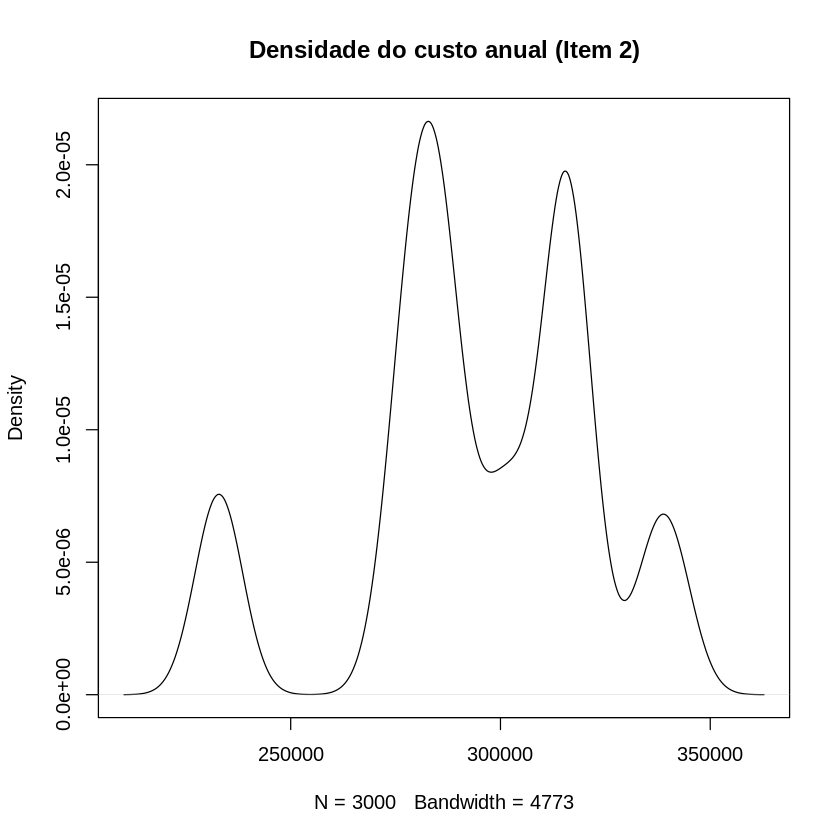

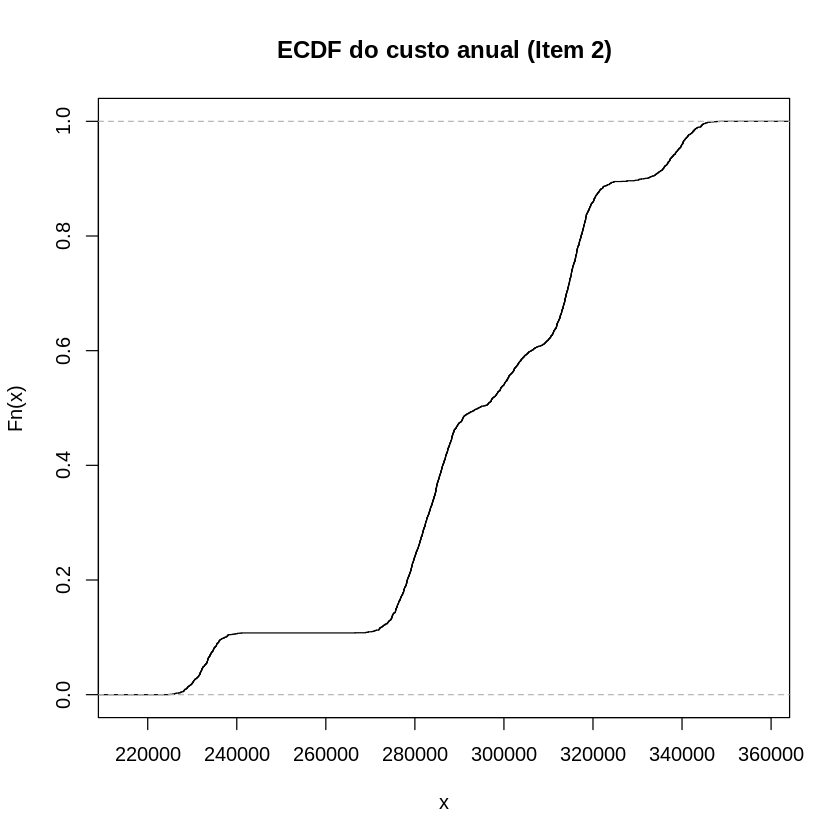

In [44]:
# Visualizações rápidas
hist(custo_anual, main = 'Histograma do custo anual (Item 2)', xlab = 'Custo anual (R$)')
plot(density(custo_anual), main = 'Densidade do custo anual (Item 2)')
plot(ecdf(custo_anual), main = 'ECDF do custo anual (Item 2)')